In [86]:
import meep as mp
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt

resolution = 120 # pixels/unit length

wvl_min = 1.5
wvl_max = 1.6
wvl_cen = 0.5*(wvl_min+wvl_max)
fmin = 1/wvl_max
fmax = 1/wvl_min
fcen = 0.5*(fmin+fmax)
df = fmax-fmin
nfreq = 10

dpml = 1.0 #PML thickness
dsub = 1.5 + wvl_cen #substrate thickness
dpad = dsub #passind between cell and PML

k_point = mp.Vector3(0,0,0) #used for PBC

n_si = 3.43 #silicon refractive index
si = mp.Medium(index=n_si)
n_air = 1.0 #air refractive index
air = mp.Medium(index=n_air)

     block, center = (0,0,0.35)
          size (0.4,0.6,0.7)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,-2.025)
          size (1e+20,1e+20,4.05)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
     block, center = (0,0,0.35)
          size (0.4,0.6,0.7)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,-2.025)
          size (1e+20,1e+20,4.05)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)


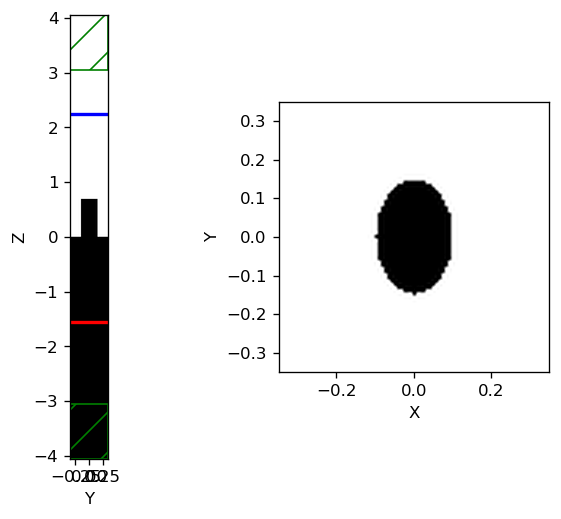

In [87]:
P = 0.7 #unit cell pitch
h = 0.7 #pillar height

sim_z_size = dpml + dsub + dpad + dpml
sim_x_size = P
sim_y_size = P

major_ax = 0.3 #major axis of the ellipse
minor_ax = 0.2 #minor axis of the ellipse

substrate_geo = mp.Block(
    material = si,
    size = mp.Vector3(mp.inf, mp.inf, dsub+dpml),
    center = mp.Vector3(0,0,-(dsub+dpml)/2),
)

ellipse_geo = mp.Ellipsoid(
    size = mp.Vector3(major_ax, minor_ax, 2*dpad),
    center = mp.Vector3(0,0,0),
    material = si,
)
ellipse_geo.do_averaging = True

cut_box_1 = mp.Block(
    material = air,
    size = mp.Vector3(major_ax, minor_ax, dpad-h),
    center = mp.Vector3(0,0,(dpad-h)/2+h)
)

cut_box_2 = mp.Block(
    material = air,
    size = mp.Vector3(major_ax, minor_ax, dpad),
    center = mp.Vector3(0,0,-dpad/2)
)

source_position = mp.Vector3(0,0,-wvl_cen) #source position in the middle of the substrate
source = mp.Source(
    mp.GaussianSource(fcen, fwidth=df),
    component = mp.Ex,
    center = source_position,
    size = mp.Vector3(sim_x_size, sim_y_size, 0),
)

cell_size = mp.Vector3(sim_x_size, sim_y_size, sim_z_size)
pml_layers = [mp.PML(dpml,direction=mp.Z)]

def elliptic_cylinder_func(p):
    # p is an mp.Vector3 point (x, y, z)
    if (p.x / (minor_ax/2)) ** 2 + (p.y / (major_ax/2)) ** 2 <= 1.0 and abs(p.z) <= h and abs(p.z) >= 0:
        return si
    return air
elliptic_cylinder_func.do_averaging = True

test_ell = mp.Block(
    center=mp.Vector3(0, 0, h/2),
    size=mp.Vector3(2*minor_ax, 2*major_ax, h),
    material=elliptic_cylinder_func,
)

sim = mp.Simulation(
    resolution = resolution,
    cell_size = cell_size,
    boundary_layers = pml_layers,
    sources = [source],
    #geometry = [ ellipse_geo, cut_box_1, cut_box_2, substrate_geo ],
    geometry = [test_ell, substrate_geo],
    material_function = elliptic_cylinder_func,
    default_material = air,
    k_point = k_point,
)

monitor_position = mp.Vector3(0,0,h+wvl_cen)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=monitor_position, size=mp.Vector3(sim_x_size, sim_y_size, 0))
)

f, ax = plt.subplots(1,2,dpi=120)
yz_plane = mp.Volume(center=mp.Vector3(0,0,0), size=mp.Vector3(0,sim_y_size,sim_z_size))
xy_plane = mp.Volume(center=mp.Vector3(0,0,h/2), size=mp.Vector3(sim_x_size,sim_y_size,0))
sim.plot2D(ax=ax[0],output_plane=yz_plane,show_sources=True,show_monitors=True)
sim.plot2D(ax=ax[1],output_plane=xy_plane,show_sources=True,show_monitors=True,show_epsilon=True)
ax[1].set_xlim(-sim_x_size/2, sim_x_size/2)
ax[1].set_ylim(-sim_y_size/2, sim_y_size/2)
plt.show()


In [88]:
obs_point = monitor_position
stop_cond = mp.stop_when_fields_decayed(25, mp.Ex, obs_point, 1e-6)
sim.run(until_after_sources=stop_cond)
eps_data = sim.get_array(center=mp.Vector3(), size=mp.Vector3(0,sim_y_size,sim_z_size), component=mp.Dielectric)
ex_data = sim.get_array(center=mp.Vector3(), size=mp.Vector3(0,sim_y_size,sim_z_size), component=mp.Ex)
plt.figure()
plt.imshow(eps_data, interpolation='spline36', cmap='binary')
plt.imshow(ex_data, interpolation='spline36', cmap='RdBu', alpha=0.9)
plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.00579405 s
Working in 3D dimensions.
Computational cell is 0.7 x 0.7 x 8.1 with resolution 120
     block, center = (0,0,0.35)
          size (0.4,0.6,0.7)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,-2.025)
          size (1e+20,1e+20,4.05)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
subpixel-averaging is 8.96239% done, 40.9949 s remaining
subpixel-averaging is 18.719% done, 17.5123 s remaining
subpixel-averaging is 28.1353% done, 10.2434 s remaining
subpixel-averaging is 37.5516% done, 6.67275 s remaining
subpixel-averaging is 47.4217% done, 4.43799 s remaining
subpixel-averaging is 57.2918% done, 3.01498 s remaining
subpixel-averaging is 66.9351% done, 1.99351 s remaining
subpixel-averaging is 77.1455% done, 1.18899 s remaining
subpixel-averaging is 87.129% done, 0.594217 s remaining
subpixel-averaging is 96.8857% done

KeyboardInterrupt: 

RuntimeError: meep: Error in typemaps

In [ ]:
input_flux = mp.get_fluxes(flux_mon)
plt.plot(np.array(input_flux)/np.max(input_flux))

In [ ]:
sim.reset_meep()

def make_unit_cell(D):
    pillar_geo = mp.Cylinder(
        material = si,
        radius = D/2,
        height = h,
        center = mp.Vector3(0,0,h/2),
    )
    return pillar_geo

def make_unit_cell_sim(D):
    pillar_geo = make_unit_cell(D)
    geometries = [substrate_geo, pillar_geo]

    sim = mp.Simulation(
        resolution = resolution,
        cell_size = cell_size,
        boundary_layers = pml_layers,
        geometry = geometries,
        default_material = air,
        k_point = k_point,
        sources = [source],
    )
    f = plt.figure(dpi=120)
    sim.plot2D(ax=f.gca(),output_plane=yz_plane,show_sources=True,show_monitors=True)
    plt.show()

    mode_mon = sim.add_flux(
        fcen, df, nfreq, mp.FluxRegion(center=monitor_position, size=mp.Vector3(sim_x_size, sim_y_size, 0))
    )
    sim.run(until_after_sources=300)

    freqs = mp.get_eigenmode_freqs(mode_mon)
    res = sim.get_eigenmode_coefficients(
        mode_mon, [1], eig_parity=mp.EVEN_Y
    )
    coeffs = res.alpha

    mode_wvl = [1/freqs[nf] for nf in range(nfreq)]
    mode_tran = [abs(coeffs[0,nf,0])**2 / input_flux[nf] for nf in range(nfreq)]
    mode_phase = [np.angle(coeffs[0,nf,0]) for nf in range(nfreq)]

    return mode_wvl, mode_tran, mode_phase

diameters = np.linspace(0.1, 0.7, 4)
mode_tran_arr = np.empty((len(diameters), nfreq))
mode_phase_arr = np.empty((len(diameters), nfreq))

for i, D in enumerate(diameters):
    mode_wvl, mode_tran, mode_phase = make_unit_cell_sim(D)
    mode_tran_arr[i,:] = mode_tran
    mode_phase_arr[i,:] = mode_phase

#make a 2d plot of the transmission and phase as a function of wavelength and diameter
plt.figure(dpi=120)
plt.subplot(2,1,1)
plt.imshow(mode_tran_arr, extent=[wvl_min*1e6, wvl_max*1e6, diameters[0], diameters[-1]], aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Transmission')
plt.ylabel('Diameter (um)')
plt.title('Transmission vs Wavelength and Diameter')
plt.subplot(2,1,2)
plt.imshow(mode_phase_arr, extent=[wvl_min*1e6, wvl_max*1e6, diameters[0], diameters[-1]], aspect='auto', origin='lower', cmap='twilight')
plt.colorbar(label='Phase (radians)')
plt.ylabel('Diameter (um)')
plt.xlabel('Wavelength (um)')
plt.title('Phase vs Wavelength and Diameter')
plt.tight_layout()
plt.show()

In [ ]:
print(input_flux[0])